# Confusion matrix for a single run

Row-normalized confusion matrix (predicted vs. true perturbation type) for one benchmark run, one panel per model -- same-view only, since mixing same-view and cross-view predictions into one matrix would blur together two different-difficulty tasks (see `src/evaluate_models.py`'s docstring). A separate macro-F1 table below reports same-view and cross-view side by side. Set `OUTPUT_DIR`/`DATASET_DIR` below to point at any `outs/<run>` + matching `<run>` dataset pair -- e.g. `outs/NFINITE100_depth` + `NFINITE100_depth` for the depth-pass run, or any run built with `create_perturbation_dataset.py --cross-view` to get real cross-view numbers.

Uses `load_predictions`/`macro_metrics` from `src/evaluate_models.py`, so it's scoring the exact same joined predictions/ground-truth the CLI and `analyze_experiment.ipynb` use.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.evaluate_models import load_predictions, macro_metrics

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Which run to look at -- any outs/<name> directory with a matching <name> dataset
# directory at the repo root (see analyze_experiment.ipynb for the full pass sweep).
# NFINITE100-CROSS is built with --cross-view, so it's the one with real cross-view
# responses to show in the macro-F1 table below.
OUTPUT_DIR = REPO_ROOT / "outs" / "NFINITE100-CROSS"
DATASET_DIR = REPO_ROOT / "NFINITE100-CROSS"

KNOWN_MODEL_ORDER = ["gpt51", "opus", "qwen235_instruct", "qwen32_instruct", "gemini35", "gemini31", "gemma4", "qwen8_instruct", "qwen8_thinking"]
CLASS_ORDER = ["count", "scale", "rotation", "placement", "none"]
# Display names for the confusion matrix only -- true_type/predicted_type still use
# evaluate_models.py's internal vocabulary (count/scale/rotation/placement/none) for indexing,
# crosstabs, and every other computation; this dict only renames what's drawn on the axes.
CLASS_LABELS = {"count": "removal", "scale": "scaling", "placement": "translation"}

# Single-hue sequential ramp (blue, light -> dark), same palette used elsewhere in these notebooks.
SEQUENTIAL_CMAP = "Blues"

# Poster-friendly typography: bigger, bolder, one consistent sans-serif everywhere (falls back
# gracefully if Lato isn't installed). Centralized here via rcParams rather than passed to every
# plot call, so every chart in this notebook stays visually consistent automatically.
plt.rcParams.update({
    "font.family": ["Lato", "Nimbus Sans", "DejaVu Sans", "sans-serif"],
    "font.size": 13,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.titlesize": 20,
    "figure.titleweight": "bold",
})

# include_cross_view=True: needed for the macro-F1 table below to have a "cross" column at
# all. Confusion-matrix plotting further down deliberately uses same_view_df, not this frame
# directly -- see the section markdown above for why the two views aren't mixed in one matrix.
predictions_df = load_predictions(OUTPUT_DIR, DATASET_DIR, include_cross_view=True)
same_view_df = predictions_df[predictions_df["view"] == "same"]

# Known models keep a fixed, readable order; anything unrecognized is still shown, appended
# alphabetically, rather than silently dropped.
present_models = set(predictions_df["model"].unique())
models = [m for m in KNOWN_MODEL_ORDER if m in present_models] + sorted(present_models - set(KNOWN_MODEL_ORDER))

n_same = (predictions_df["view"] == "same").sum()
n_cross = (predictions_df["view"] == "cross").sum()
print(f"{len(predictions_df)} scored predictions ({n_same} same-view, {n_cross} cross-view) for {OUTPUT_DIR.relative_to(REPO_ROOT)} across {len(models)} model(s): {models}")

21205 scored predictions (5293 same-view, 15912 cross-view) for outs/NFINITE100-CROSS across 9 model(s): ['gpt51', 'opus', 'qwen235_instruct', 'qwen32_instruct', 'gemini35', 'gemini31', 'gemma4', 'qwen8_instruct', 'qwen8_thinking']


## Macro F1: same-view vs. cross-view

Mean F1 over the four perturbation classes (count/scale/rotation/placement) only -- `none` excluded, matching `macro_metrics`/`_macro_f1` in `src/evaluate_models.py`. "cross" is `NaN` for a model with no `_view<n>.json` responses in this run.

In [3]:
macro_f1 = macro_metrics(predictions_df)["macro_f1"].unstack("view")
macro_f1 = macro_f1.reindex(index=models, columns=["same", "cross"])
macro_f1.round(3)

view,same,cross
model,,
gpt51,0.283,0.305
opus,0.452,0.348
qwen235_instruct,0.201,0.210
qwen32_instruct,0.310,0.272
gemini35,0.291,0.188
gemini31,0.373,0.318
gemma4,0.334,0.296
qwen8_instruct,0.148,0.206
qwen8_thinking,0.170,0.204


## `plot_confusion_matrix`

Draws one model's row-normalized confusion matrix. Pass `ax` to draw into an existing subplot (used below to build the all-models grid); omit it to get a standalone figure with its own colorbar.

In [4]:
def plot_confusion_matrix(predictions_df, model, class_order=CLASS_ORDER, class_labels=CLASS_LABELS, cmap=SEQUENTIAL_CMAP, ax=None, save_path=None):
    """Row-normalized confusion matrix for one model. Returns the imshow handle.

    class_order indexes the underlying crosstab (must match true_type/predicted_type's actual
    values); class_labels only renames what's drawn on the axes, via class_labels.get(cls, cls)
    -- a class left out of the dict (e.g. "none") is shown under its own name unchanged.

    Pass save_path (e.g. "opus_confusion.pdf") to also export a print-resolution copy --
    PDF/SVG stay crisp at poster size; a high-DPI PNG works too.
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6.6, 6.2))

    n = len(class_order)
    display_labels = [class_labels.get(cls, cls) for cls in class_order]
    group = predictions_df[predictions_df["model"] == model]
    counts = pd.crosstab(group["true_type"], group["predicted_type"]).reindex(
        index=class_order, columns=class_order, fill_value=0
    )
    support = counts.sum(axis=1)
    pct = counts.div(support.replace(0, np.nan), axis=0).mul(100)

    im = ax.imshow(pct.values, cmap=cmap, vmin=0, vmax=100, aspect="auto")

    ax.set_xticks(range(n))
    ax.set_xticklabels(display_labels, rotation=30, ha="right")
    ax.set_yticks(range(n))
    ax.set_yticklabels([f"{label}\n(n={support[cls]})" for cls, label in zip(class_order, display_labels)])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    # ax.set_title(model, pad=12)

    # Thin white separators between cells (classic clean matrix look) instead of a plain
    # axes frame, which reads as chart junk here -- the cells' own edges are the only
    # gridlines this chart needs.
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(which="major", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for r, true_cls in enumerate(class_order):
        for c, pred_cls in enumerate(class_order):
            value = pct.values[r, c]
            if np.isnan(value):
                continue
            is_diagonal = r == c
            text_color = "white" if value > 55 else "#0b0b0b"
            ax.text(
                c, r, f"{value:.0f}",
                ha="center", va="center", color=text_color, fontsize=14,
                fontweight="bold" if is_diagonal else "normal", zorder=4,
            )
            if is_diagonal:
                # Outline the "correct" cell so it's findable without reading every number.
                # zorder above the minor gridlines (their default is ~2.5), otherwise the
                # white grid lines paint straight over this outline and it never shows.
                ax.add_patch(plt.Rectangle(
                    (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="#0b0b0b", linewidth=2.5, zorder=3
                ))

    if standalone:
        cbar = fig.colorbar(im, ax=ax, label="% of true class", fraction=0.046, pad=0.04)
        cbar.outline.set_visible(False)
        fig.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

    return im

### Single model

Call it directly with any model name from `models` to print just that one.

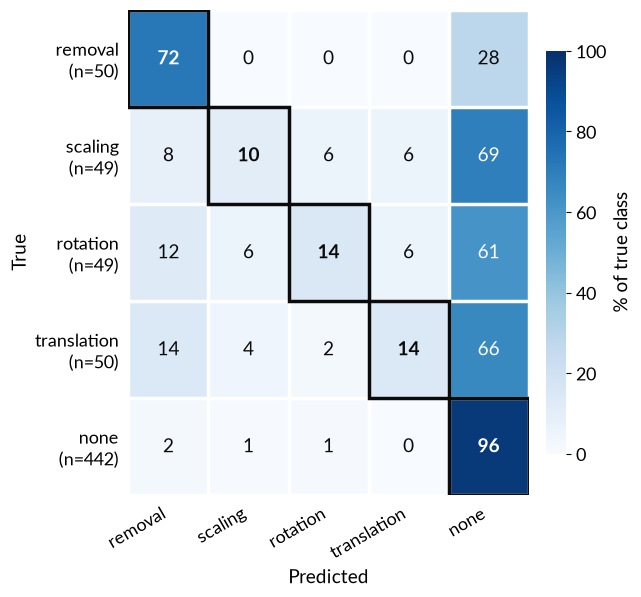

In [5]:
plot_confusion_matrix(same_view_df, "qwen32_instruct")

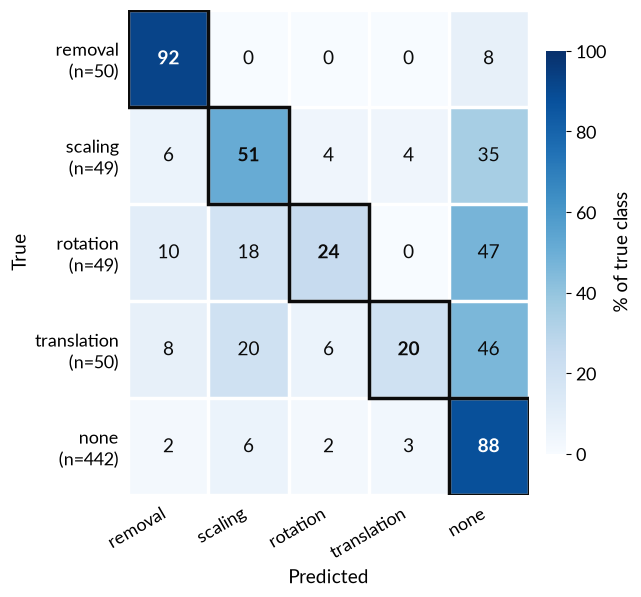

In [5]:
plot_confusion_matrix(same_view_df, "opus")

### All models

Same helper, called once per model into a shared 2-column grid. Each cell is the percentage of a true class's objects (row) the model assigned to a given predicted class (column) -- rows sum to 100%.

In [ ]:
n_cols = 2
n_rows = -(-len(models) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.6 * n_cols, 6.2 * n_rows))
axes = np.atleast_1d(axes).flatten()

im = None
for ax, model in zip(axes, models):
    im = plot_confusion_matrix(same_view_df, model, ax=ax)

# Hide any unused grid cells (odd number of models).
for ax in axes[len(models):]:
    ax.set_visible(False)

fig.suptitle(f"Confusion matrix (same-view) -- {OUTPUT_DIR.relative_to(REPO_ROOT)}", y=1.02)
# Each panel has its own (differently-sized) row labels, so give them breathing room --
# without this, one panel's labels overlap the neighboring panel's cells. Reserve room on
# the right for the colorbar too, and do both before placing it, so the colorbar isn't
# squeezed by a layout change that happens after it's already claimed its space.
fig.subplots_adjust(wspace=0.7, hspace=0.65, right=0.9)
cbar = fig.colorbar(im, ax=list(axes), label="% of true class", fraction=0.02, pad=0.02)
cbar.outline.set_visible(False)

# e.g. fig.savefig(REPO_ROOT / "assets" / "confusion_matrix_grid.pdf", dpi=300, bbox_inches="tight")
plt.show()